In [24]:
# %pip install xgboost

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

# models 
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier 
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# set style 
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

In [26]:
# load dataset 
data = load_breast_cancer()
X = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target
X.head()

# split data 
X_train , X_test,y_train , y_test = train_test_split(
    X,y,
    test_size=0.25,
    random_state=42
)

print(f"Traning sample = {X_train.shape[0]}")
print(f"Testing sample = {X_test.shape[0]}")


Traning sample = 426
Testing sample = 143


In [27]:
# model 

models = {
    "Random Forest \n(Bagging)":RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42),
    "XGBoost Boosting": XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42,eval_metric="logloss")
    
}
predictions = {}
accuracies = {}

for name , model in models.items():
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    acc = accuracy_score(y_test,pred)
    accuracies[name] = acc
    print(f"{name:20} accuracy {acc:.4f} ({acc*100:.2f}%)")

Random Forest 
(Bagging) accuracy 0.9650 (96.50%)
Gradient Boosting    accuracy 0.9580 (95.80%)
XGBoost Boosting     accuracy 0.9580 (95.80%)


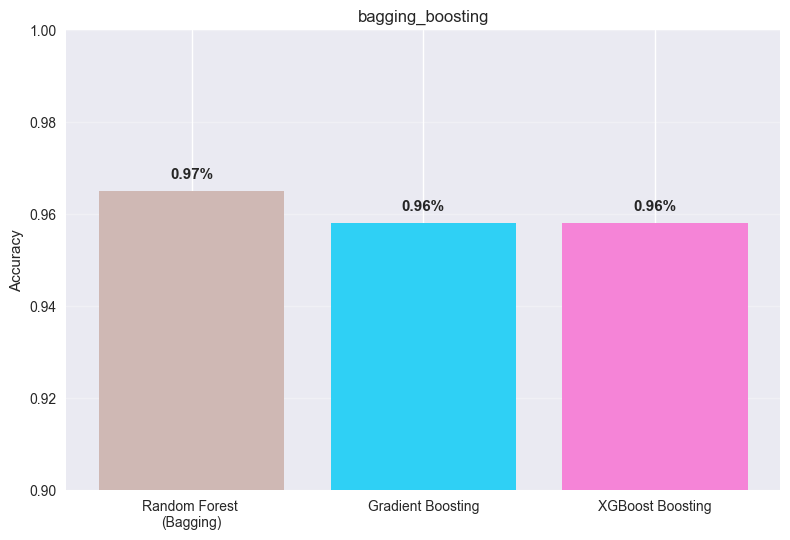

In [ ]:
plt.Figure(figsize=(10,6))
bars = plt.bar(accuracies.keys(),accuracies.values(),color=['#CFB8B4','#2FD0F5',"#F584D7"])
plt.title("bagging_boosting")
plt.ylabel("Accuracy")
plt.ylim(0.9,1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.,height+0.002,f"{height:.2f}%",ha='center',va='bottom',fontsize=11,fontweight='bold')
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show() 

    

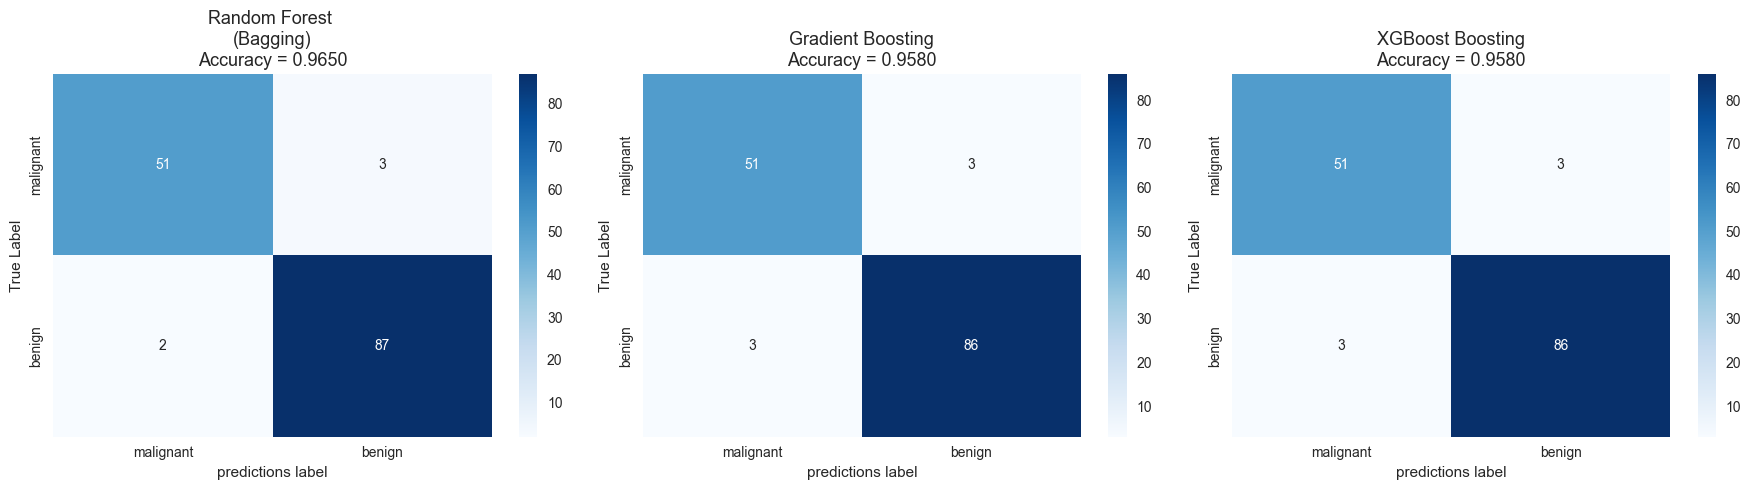

In [35]:
fig , axes = plt.subplots(1,3,figsize=(18,5))
for i, (name,pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test,pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
                xticklabels=data.target_names,
                yticklabels=data.target_names,
                ax=axes[i])
    axes[i].set_title(f"{name}\nAccuracy = {accuracies[name]:.4f}", fontsize=13)
    axes[i].set_xlabel("predictions label")
    axes[i].set_ylabel("True Label")
    
plt.tight_layout()    
    
plt.show()    

In [40]:
print(classification_report(y_test,predictions["XGBoost Boosting"],target_names=data.target_names))   

              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        54
      benign       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143

